### *Crypto Price Tracker – Live Bitcoin Monitoring with Alerts*

#### ***Introduction***
*This project demonstrates how to track cryptocurrency prices in real-time using the **CoinGecko API**.  
We fetch Bitcoin (BTC) prices, update them live every minute, visualize the price trend, and trigger alerts if the price moves more than **±5% in a day**.*  

***Key Features:***
- *API integration (CoinGecko REST API).*
- *Live price updates & visualization.*
- *Auto-alerts for significant price movements.*
- *Data persistence (CSV storage).*


#### ***Import libraries & Setup***

In [1]:
# Import libraries
import time, requests, pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import clear_output, display, HTML

# Configuration
url = "https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd"
interval_sec = 60              # update frequency (sec)
alert_threshold_pct = 5.0      # % movement for alert
max_iterations = 0             # 0 = run forever
save_path = "btc_prices.csv"
save_alert_path = "btc_prices_alert.csv"

#### ***Testing API Connection***

In [2]:
# ✅ Quick test: check API response
res = requests.get(url).json()
print(res)

{'bitcoin': {'usd': 115014}}


##### *This API is working and returns live BTC price data*

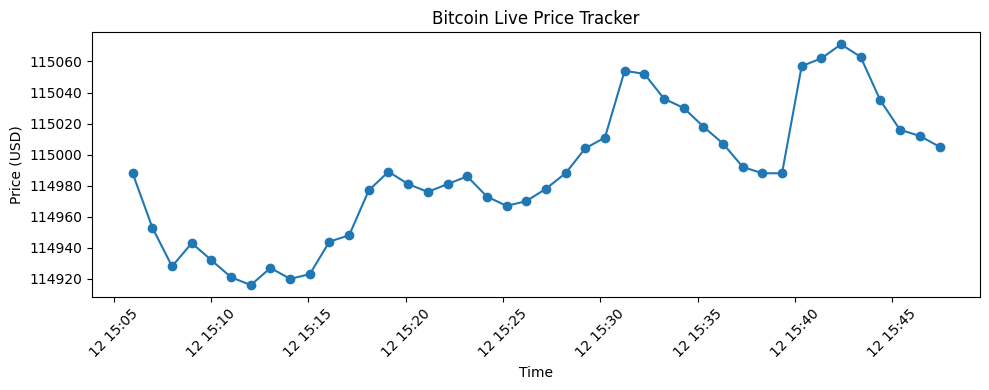

[2025-09-12 15:47:26] Price: $115,005 | Change: 0.01%

Stopped by user. Latest data saved to: btc_prices.csv


In [3]:
# ✅ Live tracker loop
data = pd.DataFrame(columns=["Time", "Price"])
start_price = None
iteration = 0

try:
    while True:
        iteration += 1
        # 1. fetch
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        res = resp.json()
        btc_price = res["bitcoin"]["usd"]
        now = datetime.now()

        # 2. baseline (first price = baseline)
        if start_price is None:
            start_price = btc_price

        # 3. append
        data = pd.concat([data, pd.DataFrame({"Time":[now], "Price":[btc_price]})], ignore_index=True)

        # 4. compute % change
        change = ((btc_price - start_price) / start_price) * 100

        # 5. clear + redraw chart
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10,4))
        ax.plot(data["Time"], data["Price"], marker="o")
        ax.set_title("Bitcoin Live Price Tracker")
        ax.set_xlabel("Time")
        ax.set_ylabel("Price (USD)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 6. print update
        print(f"[{now.strftime('%Y-%m-%d %H:%M:%S')}] Price: ${btc_price:,} | Change: {change:.2f}%")

        # 7. alert if threshold crossed
        if abs(change) >= alert_threshold_pct:
            msg = f"⚠️ ALERT! Bitcoin moved {change:.2f}% since tracking started: ${start_price:,} → ${btc_price:,}"
            print(msg)
            display(HTML(f"<h2 style='color:red'>{msg}</h2>"))
            data.to_csv(save_alert_path, index=False)

        # 8. save history
        data.to_csv(save_path, index=False)

        # 9. stop if max_iterations reached
        if max_iterations and iteration >= max_iterations:
            print("Reached max_iterations — stopping.")
            break

        time.sleep(interval_sec)

except KeyboardInterrupt:
    print("\nStopped by user. Latest data saved to:", save_path)

#### ***Conclusion***

- *Successfully built a **real-time BTC tracker**.*  
- *Connected to the **CoinGecko API** for live prices.*  
- *Implemented **alerts for ±5% price movement**.*  *
- *Data is stored in **CSV format** for later analysis.*  